11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 32ms/step - accuracy: 0.9494 - loss: 0.1634 - val_accuracy: 0.9813 - val_loss: 0.0636
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 34ms/step - accuracy: 0.9832 - loss: 0.0540 - val_accuracy: 0.9853 - val_loss: 0.0513
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 33ms/step - accuracy: 0.9880 - loss: 0.0376 - val_accuracy: 0.9898 - val_loss: 0.0382
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9917 - loss: 0.0270 - val_accuracy: 0.9898 - val_loss: 0.0391
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9933 - loss: 0.0206 - val_accuracy: 0.9891 - val_loss: 0.0402
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9903 - loss: 0.0291
Test Accuracy: 0.9902999997138977


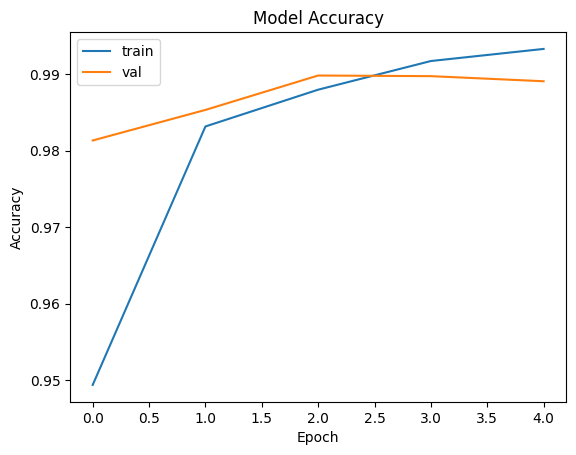

In [1]:
# ================= STEP 1: IMPORT =================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# ================= STEP 2: LOAD DATA =================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train shape:", x_train.shape)

# ================= STEP 3: NORMALIZATION =================
x_train = x_train / 255.0
x_test = x_test / 255.0

# ================= STEP 4: RESHAPE =================
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# ================= STEP 5: BUILD CNN =================
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# ================= STEP 6: COMPILE =================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ================= STEP 7: TRAIN =================
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# ================= STEP 8: EVALUATE =================
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# ================= STEP 9: VISUALIZE =================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()